>>> [1/4] 正在加载数据...
>>> [2/4] 正在启动 AutoML 搜索最佳模型 (限时60秒)...
[flaml.automl.logger: 03-28 10:58:28] {2375} INFO - task = classification
[flaml.automl.logger: 03-28 10:58:28] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 03-28 10:58:28] {2489} INFO - Minimizing error metric: 1-f1
[flaml.automl.logger: 03-28 10:58:28] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 03-28 10:58:28] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 03-28 10:58:29] {3046} INFO - Estimated sufficient time budget=415s. Estimated necessary time budget=10s.
[flaml.automl.logger: 03-28 10:58:29] {3097} INFO -  at 0.0s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 03-28 10:58:29] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 03-28 10:58:29] {3097} INFO -  at 0.1s,	estimator lgbm's best error=1.0000e+00,	be

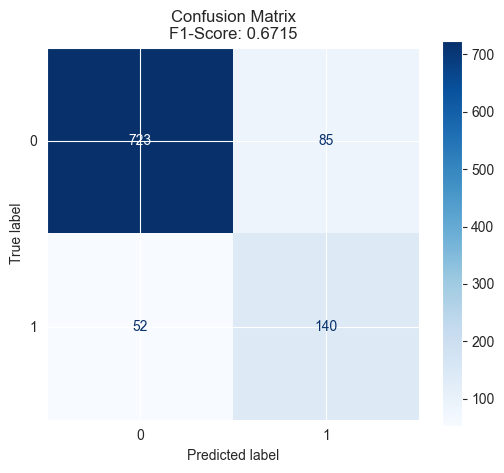


>>> [4/4] 正在执行降维计算 (PCA 与 t-SNE)...
所有任务已完成。


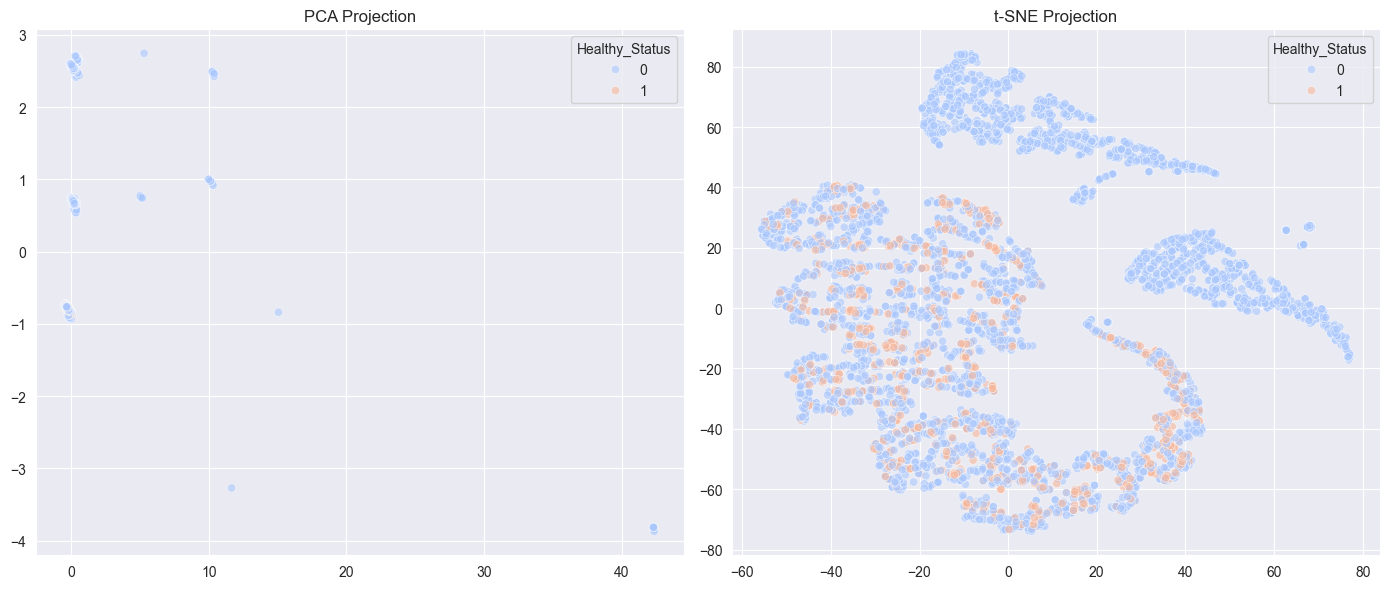

In [10]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay

# 尝试导入 FLAML
try:
    from flaml import AutoML
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "flaml"])
    from flaml import AutoML

# --- 1. 数据加载与预处理 ---
print(">>> [1/4] 正在加载数据...")
url = "https://raw.githubusercontent.com/AI-is-out-there/data2lab/refs/heads/main/%D0%BC%D0%BE%D0%B4%D1%83%D0%BB%D1%8C%203%20-%20%D0%B4%D0%B0%D1%82%D0%B0%D1%81%D0%B5%D1%82%20-%20%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0.csv"
selected_cols = ['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 'qrs_end', 'p_axis', 'qrs_axis', 't_axis', 'Healthy_Status']

df = pd.read_csv(url, nrows=5000, sep=';')
if len(df.columns) < 2: df = pd.read_csv(url, nrows=5000, sep=',')
df = df[selected_cols].dropna()

X = df.drop(columns=['Healthy_Status'])
y = df['Healthy_Status']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. AutoML 训练 (修复参数兼容性) ---
print(">>> [2/4] 正在启动 AutoML 搜索最佳模型 (限时60秒)...")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

automl = AutoML()
# 移除了引发错误的 'verbosity'，改用更稳健的配置
settings = {
    "time_budget": 60,
    "metric": 'f1',
    "task": 'classification',
    "seed": 42
}

# 运行训练
automl.fit(X_train=X_train, y_train=y_train, **settings)

# --- 3. 立即输出结果与混淆矩阵 ---
print("\n" + "="*40)
print("【ОСНОВНЫЕ РЕЗУЛЬТАТЫ ЗАДАНИЯ】")
y_pred = automl.predict(X_test)
final_f1 = f1_score(y_test, y_pred)
print(f"Лучший алгоритм модели: {automl.best_estimator}")
print(f"Показатель F1 на тестовой выборке: {final_f1:.4f}")
print("="*40)

print("\n>>> [3/4] 正在展示混淆矩阵...")
cm = confusion_matrix(y_test, y_pred)
fig1, ax1 = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=automl.classes_)
disp.plot(cmap='Blues', ax=ax1, values_format='d')
plt.title(f'Confusion Matrix\nF1-Score: {final_f1:.4f}')
plt.show()

# --- 4. 降维可视化 ---
print("\n>>> [4/4] 正在执行降维计算 (PCA 与 t-SNE)...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

fig2, (ax_pca, ax_tsne) = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm', alpha=0.6, ax=ax_pca)
ax_pca.set_title('PCA Projection')
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='coolwarm', alpha=0.6, ax=ax_tsne)
ax_tsne.set_title('t-SNE Projection')

plt.tight_layout()
print("所有任务已完成。")
plt.show()